<a href="https://colab.research.google.com/github/CuicuiZhang01/Cuicui__INFO5731_Spring2026/blob/main/Zhang_Cuicui_Assignment_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================
# Load dataset
# =========================
data = pd.read_csv('Tweets.csv')

data.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [ ]:
print(data['airline_sentiment'].value_counts())

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [ ]:
# =========================
# Keep useful columns
# =========================
data = data[['text', 'airline_sentiment', 'airline']]
data.dropna(inplace=True)
data.head()

,text,airline_sentiment,airline
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America
3,@VirginAmerica it's really aggressive to blast...,negative,Virgin America
4,@VirginAmerica and it's a really big bad thing...,negative,Virgin America


In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# =========================
# Text cleaning function
# =========================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)          # remove mentions
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text) # remove URLs
    text = re.sub(r'#', '', text)                        # remove hashtag symbol only
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)             # keep letters only
    tokens = word_tokenize(text)                         # tokenization
    tokens = [word for word in tokens if word not in stop_words]  # stopword removal
    tokens = [lemmatizer.lemmatize(word) for word in tokens]      # lemmatization
    return " ".join(tokens)

data['clean_text'] = data['text'].apply(clean_text)

# remove empty rows after cleaning
data = data[data['clean_text'].str.strip() != '']
data.head()

,text,airline_sentiment,airline,clean_text
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America,said
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America,plus added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America,today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,negative,Virgin America,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,negative,Virgin America,really big bad thing


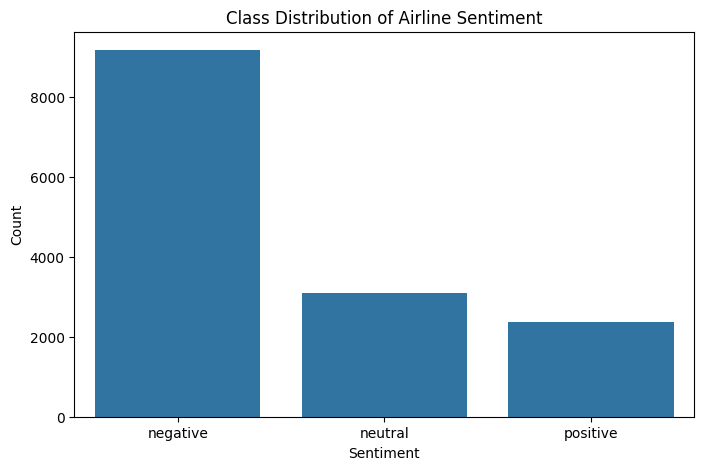

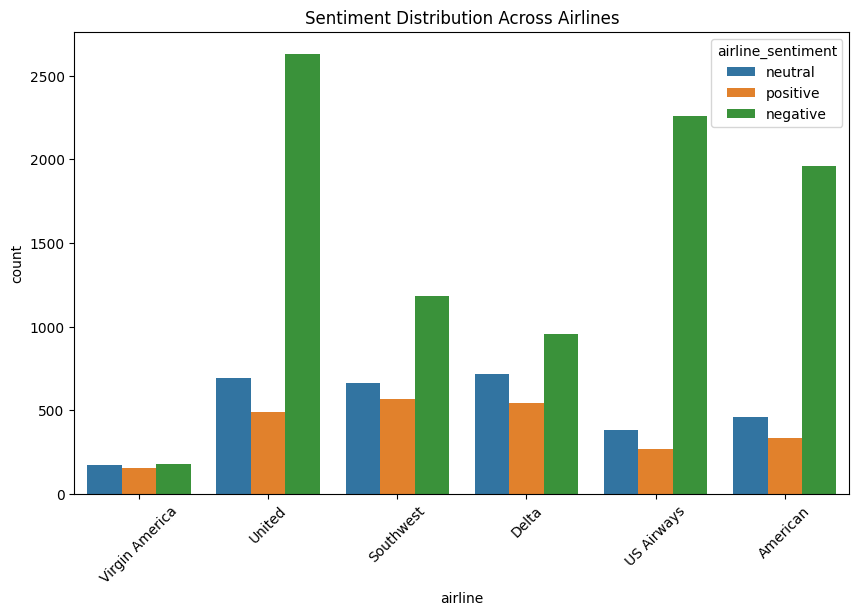

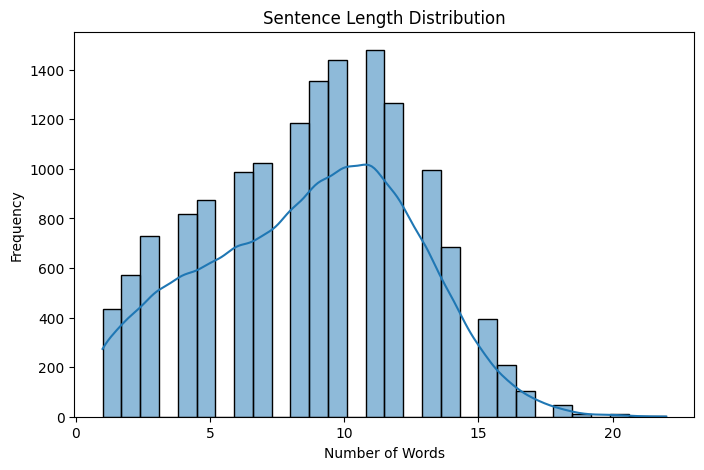

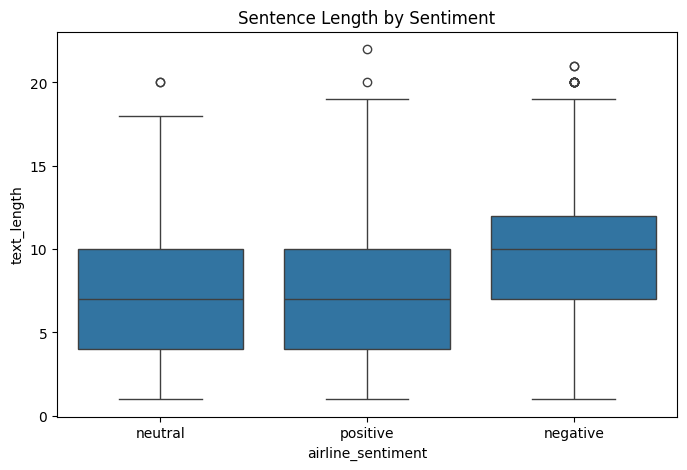

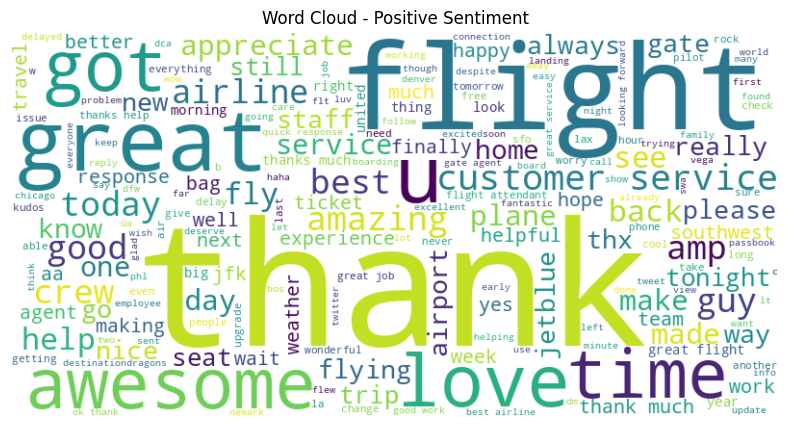

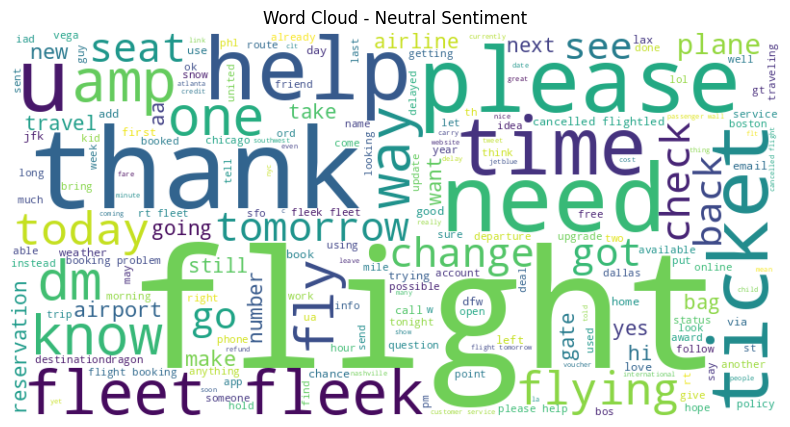

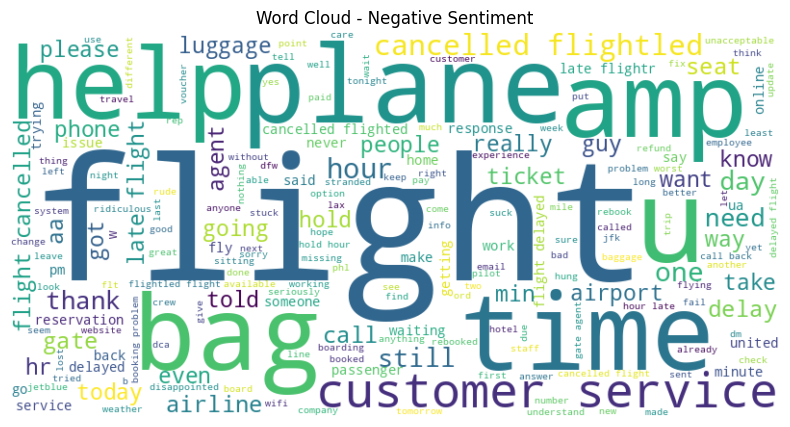

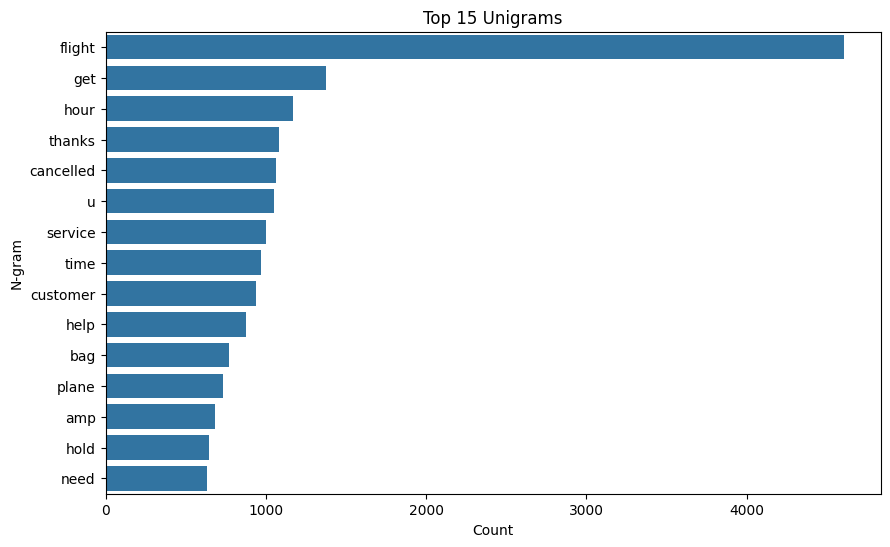

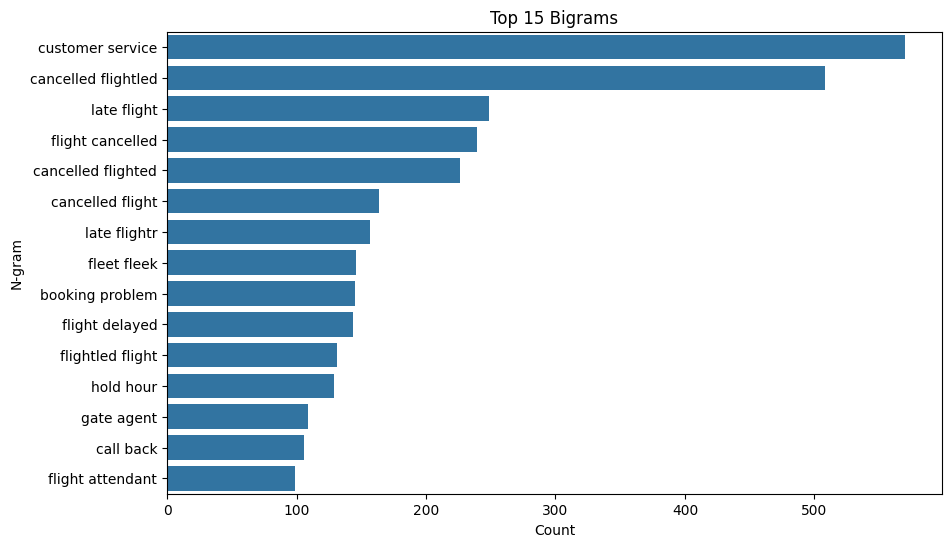

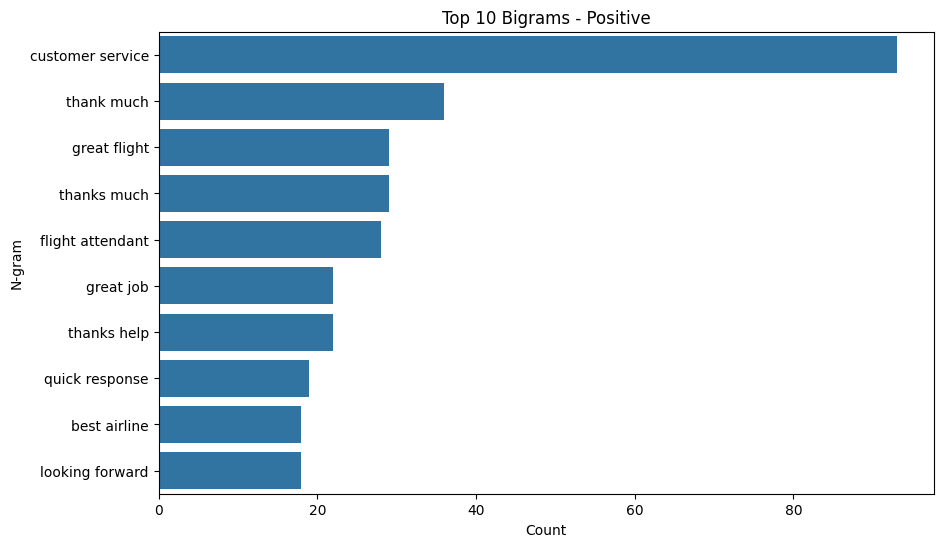

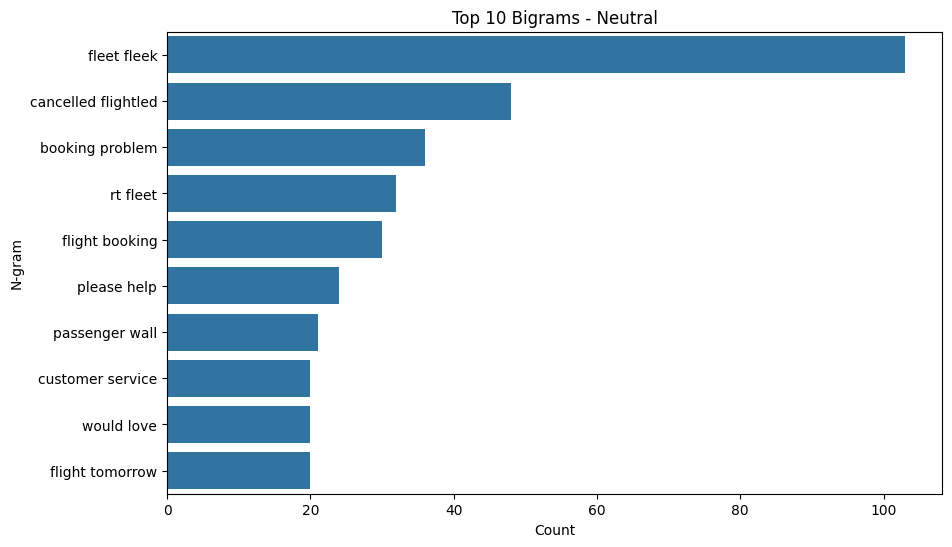

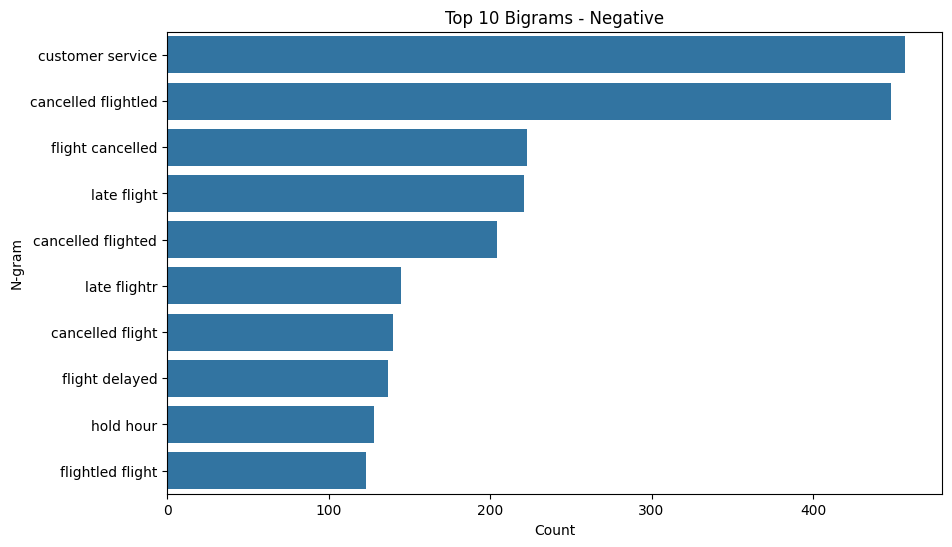

In [ ]:
# =========================
# EDA
# =========================

# 1. Class distribution
plt.figure(figsize=(8,5))
sns.countplot(x='airline_sentiment', data=data, order=data['airline_sentiment'].value_counts().index)
plt.title('Class Distribution of Airline Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# 2. Airline distribution by sentiment
plt.figure(figsize=(10,6))
sns.countplot(x='airline', hue='airline_sentiment', data=data)
plt.title('Sentiment Distribution Across Airlines')
plt.xticks(rotation=45)
plt.show()

# 3. Sentence length analysis
data['text_length'] = data['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(data['text_length'], bins=30, kde=True)
plt.title('Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='airline_sentiment', y='text_length', data=data)
plt.title('Sentence Length by Sentiment')
plt.show()

# 4. Word clouds
for sentiment in ['positive', 'neutral', 'negative']:
    text_data = " ".join(data[data['airline_sentiment'] == sentiment]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {sentiment.capitalize()} Sentiment')
    plt.show()

# 5. N-gram analysis function
def plot_top_ngrams(text_series, n=1, top_k=15, title='Top N-grams'):
    all_words = []
    for text in text_series:
        words = text.split()
        ngrams = zip(*[words[i:] for i in range(n)])
        all_words.extend([' '.join(ngram) for ngram in ngrams])

    counter = Counter(all_words)
    common = counter.most_common(top_k)

    ngram_words = [x[0] for x in common]
    ngram_counts = [x[1] for x in common]

    plt.figure(figsize=(10,6))
    sns.barplot(x=ngram_counts, y=ngram_words)
    plt.title(title)
    plt.xlabel('Count')
    plt.ylabel('N-gram')
    plt.show()

# Top unigrams
plot_top_ngrams(data['clean_text'], n=1, top_k=15, title='Top 15 Unigrams')

# Top bigrams
plot_top_ngrams(data['clean_text'], n=2, top_k=15, title='Top 15 Bigrams')

# n-grams by sentiment
for sentiment in ['positive', 'neutral', 'negative']:
    plot_top_ngrams(
        data[data['airline_sentiment'] == sentiment]['clean_text'],
        n=2,
        top_k=10,
        title=f'Top 10 Bigrams - {sentiment.capitalize()}'
    )

In [ ]:
# =========================
# Features and target
# =========================
X = data['clean_text']
y = data['airline_sentiment']

# Encode target manually for XGBoost
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
y_encoded = y.map(label_map)

# Train-test split
X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X, y, y_encoded, test_size=0.2, random_state=42, stratify=y
)

# =========================
# TF-IDF Vectorization
# =========================
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (11690, 5000)
X_test_tfidf shape: (2923, 5000)


SVM Accuracy: 0.7440985289086555
SVM Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.77      0.83      1834
     neutral       0.52      0.68      0.59       617
    positive       0.66      0.71      0.68       472

    accuracy                           0.74      2923
   macro avg       0.69      0.72      0.70      2923
weighted avg       0.77      0.74      0.75      2923



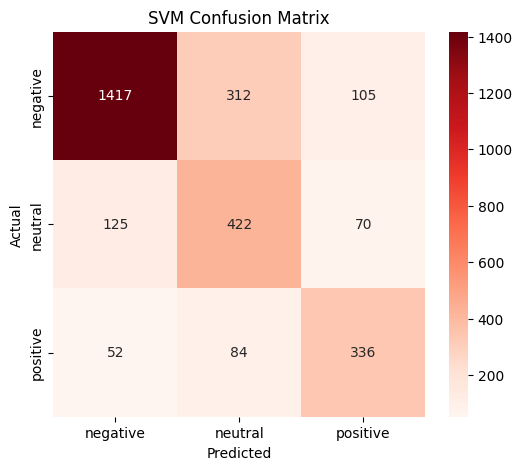

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights_xgb = compute_sample_weight(class_weight='balanced', y=y_train_enc)

# =========================
# Model 1: SVM
# =========================
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("SVM Classification Report:")
print(classification_report(y_test, svm_pred))

svm_cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(6,5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# 5-fold cross validation-SVM
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear']
}

svm = SVC(class_weight='balanced', random_state=42)

grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_svm = grid.best_estimator_
pred = best_svm.predict(X_test_tfidf)

print("Test Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Best Params: {'C': 1, 'kernel': 'linear'}
Best CV Score: 0.7341317365269462
Test Accuracy: 0.7393089291823469
              precision    recall  f1-score   support

    negative       0.88      0.77      0.82      1834
     neutral       0.51      0.67      0.58       617
    positive       0.66      0.71      0.68       472

    accuracy                           0.74      2923
   macro avg       0.68      0.72      0.69      2923
weighted avg       0.77      0.74      0.75      2923



Naive Bayes Accuracy: 0.7300718439958946
Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.77      0.82      1834
     neutral       0.53      0.59      0.56       617
    positive       0.59      0.75      0.66       472

    accuracy                           0.73      2923
   macro avg       0.66      0.70      0.68      2923
weighted avg       0.75      0.73      0.74      2923



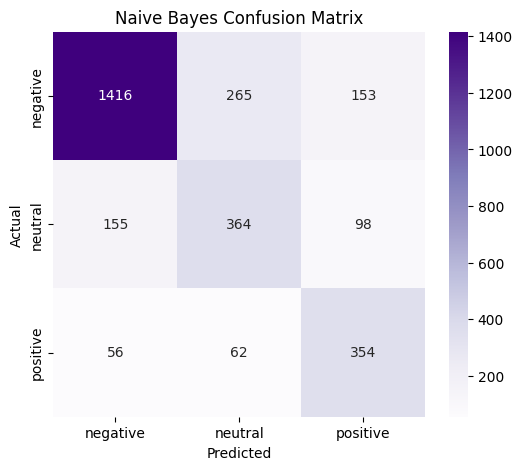

XGBoost Accuracy: 0.6941498460485802
XGBoost Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.69      0.78      1834
     neutral       0.44      0.73      0.55       617
    positive       0.64      0.67      0.66       472

    accuracy                           0.69      2923
   macro avg       0.66      0.70      0.66      2923
weighted avg       0.76      0.69      0.71      2923



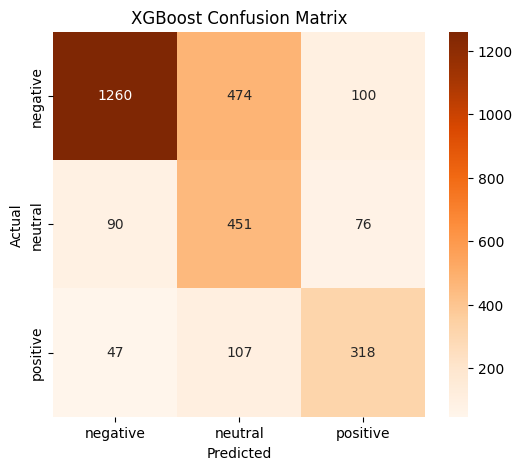

In [ ]:
# =========================
# Model 2: Naive Bayes
# =========================
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Naive Bayes Classification Report:")
print(classification_report(y_test, nb_pred))

nb_cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(6,5))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# =========================
# Model 3: XGBoost
# =========================
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train_tfidf, y_train_enc, sample_weight=sample_weights_xgb)
xgb_pred_enc = xgb_model.predict(X_test_tfidf)

reverse_label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
xgb_pred = pd.Series(xgb_pred_enc).map(reverse_label_map)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

xgb_cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,5))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:

# =========================
# Model 4: BERT
# =========================

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset

# label mapping
label_map = {'negative':0, 'neutral':1, 'positive':2}
data['label'] = data['airline_sentiment'].map(label_map)

# train/test split
train_df, test_df = train_test_split(data[['text','label']], test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
    return tokenizer(example['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids','attention_mask','label'])
test_dataset.set_format(type='torch', columns=['input_ids','attention_mask','label'])

# model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

# training args
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    eval_strategy="epoch",
    logging_dir='./logs'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

# evaluation
results = trainer.evaluate()
print("BERT Results:", results)

Map:   0%|          | 0/11690 [00:00<?, ? examples/s]

Map:   0%|          | 0/2923 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss
1,0.519808,0.411310
2,0.348550,0.427732


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Results: {'eval_loss': 0.4277316629886627, 'eval_runtime': 25.5344, 'eval_samples_per_second': 114.473, 'eval_steps_per_second': 14.334, 'epoch': 2.0}


BERT Accuracy: 0.8546014368799179
BERT Precision: 0.8528989885485766
BERT Recall: 0.8546014368799179
BERT F1-score: 0.853496286792723

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.92      0.91      1857
     neutral       0.76      0.71      0.73       641
    positive       0.78      0.80      0.79       425

    accuracy                           0.85      2923
   macro avg       0.81      0.81      0.81      2923
weighted avg       0.85      0.85      0.85      2923



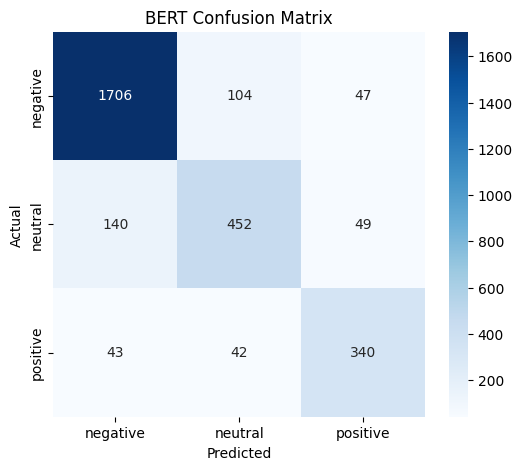

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Get predictions
# =========================
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# =========================
# Calculate metrics
# =========================
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

print("BERT Accuracy:", accuracy)
print("BERT Precision:", precision)
print("BERT Recall:", recall)
print("BERT F1-score:", f1)

# =========================
# Classification report
# =========================
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=['negative','neutral','positive']
))

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title('BERT Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

1.This task uses a dataset from Kaggle that contains tweets related to airlines posted by users on Twitter. The dataset consists of 14,640 rows and 15 columns. For text sentiment classification, the selected features mainly include text (tweet content), airline (airline name), and airline_sentiment (sentiment label). Among them, text is used as the input feature, and airline_sentiment is used as the target variable, with three classes: negative, neutral, and positive. From the data distribution, the negative class accounts for a significantly larger proportion than the neutral and positive classes, indicating a certain degree of class imbalance. This imbalance may cause the model to be biased toward predicting the majority (negative) class, thereby reducing its ability to correctly identify minority classes. To address this issue, class imbalance handling techniques were applied during model training. Specifically, the SVM model uses class_weight='balanced' to assign different weights to each class. For the Naive Bayes and XGBoost models, sample_weight is used to assign weights to individual samples, giving higher importance to minority class instances. This approach helps improve the overall fairness of the models and enhances their ability to correctly identify the neutral and positive classes.

2.During the data cleaning and preprocessing stage, regular expressions were used to remove mentions, URLs, and special characters, and all text was converted to lowercase. Tokenization was then applied, followed by stopword removal and lemmatization to normalize word forms. These steps help produce cleaner and more consistent text data, thereby improving model performance.

In the EDA stage, the class distribution plot shows that the negative class significantly outnumbers the other classes, indicating the presence of class imbalance. Among different airlines, United, US Airways, and American have notably higher numbers of negative comments. In contrast, the neutral and positive classes are smaller and more evenly distributed, further confirming the imbalance in the dataset. The sentence length distribution shows that most tweets contain between 8 and 12 words, with a relatively stable distribution that is suitable for model learning. Additionally, negative sentences tend to be longer, suggesting that users provide more detailed descriptions when expressing dissatisfaction, while neutral and positive tweets are generally shorter and more concise.

Unigram analysis reveals that words such as “flight” and “service” appear most frequently, reflecting the main topics of the dataset. However, the presence of noise words such as “u” and “amp” indicates that further text cleaning could be beneficial. Moreover, individual words have limited ability to distinguish sentiment. In contrast, bigram analysis provides more meaningful insights. Frequent phrases such as “customer service,” “cancelled flight,” and “flight delayed” clearly capture key issues faced by customers. In sentiment-specific analysis, the positive class includes phrases such as “great flight,” indicating satisfaction, while the negative class is dominated by phrases related to delays and cancellations. The neutral class mainly contains descriptive expressions with weaker sentiment signals, making it more difficult to classify. Overall, bigram analysis enhances semantic representation and helps explain the differences in model performance across sentiment categories.

3.In this task, SVM, Naive Bayes, XGBoost, and a pretrained BERT were applied to perform sentiment classification on airline tweets. In addition, cross-validation was conducted on the SVM model to verify its stability. Overall, the BERT model achieved the best performance, with an accuracy of approximately 0.85 and consistently high precision, recall, and F1-score across all classes. In comparison, traditional machine learning models showed lower performance, with SVM achieving around 0.74 accuracy, Naive Bayes around 0.73, and XGBoost the lowest at approximately 0.69.

Specifically, the SVM model demonstrated strong performance on the negative class with high precision, while maintaining relatively balanced performance across other classes. Naive Bayes showed moderate performance, with relatively high recall for the positive class but limited overall discriminative power. XGBoost performed better on the neutral class in terms of recall but struggled with the negative class, leading to lower overall performance.

From the comparison, BERT clearly outperformed the traditional models. Its advantage lies in its ability to capture contextual and semantic information in text, rather than relying solely on word frequency or n-gram features. This makes it particularly effective for handling more complex or ambiguous cases such as neutral sentiment. In contrast, SVM and Naive Bayes rely on TF-IDF-based sparse features and are more dependent on explicit keywords, which explains their strong performance on the negative class but weaker performance on neutral data. XGBoost, on the other hand, is less suitable for high-dimensional sparse text data, resulting in comparatively lower performance.
The results also highlight that negative sentiment is easier to classify due to strong and repetitive keywords, while neutral sentiment remains the most challenging category due to its lack of clear distinguishing features.

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

# =========================
# 1. Load data
# =========================
def load_data(file_path):
    texts = []
    labels = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            label, text = line.strip().split(" ", 1)  # split only once
            labels.append(int(label))
            texts.append(text)

    return pd.DataFrame({"label": labels, "text": texts})

train_data = load_data("stsa-train.txt")
test_data = load_data("stsa-test.txt")


# Basic info
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("\nTrain head:")
print(train_data.head())
print("\nTest head:")
print(test_data.head())

Train shape: (6920, 2)
Test shape: (1821, 2)

Train head:
   label                                               text
0      1  a stirring , funny and finally transporting re...
1      0  apparently reassembled from the cutting-room f...
2      0  they presume their audience wo n't sit still f...
3      1  this is a visually stunning rumination on love...
4      1  jonathan parker 's bartleby should have been t...

Test head:
   label                                               text
0      0     no movement , no yuks , not much of anything .
1      0  a gob of drivel so sickly sweet , even the eag...
2      0  gangs of new york is an unapologetic mess , wh...
3      0  we never really feel involved with the story ,...
4      1            this is one of polanski 's best films .


Train distribution:
 label
1    3610
0    3310
Name: count, dtype: int64


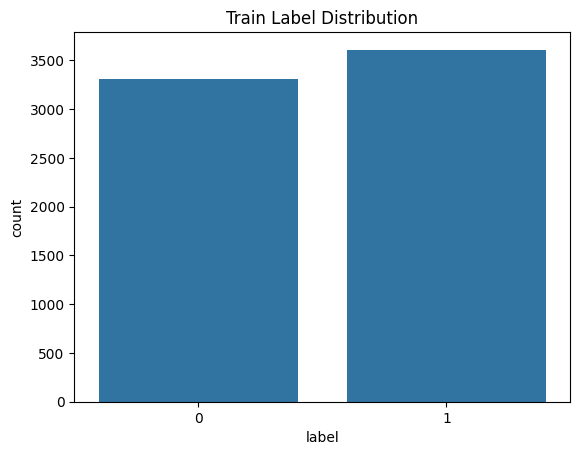

Test distribution:
 label
0    912
1    909
Name: count, dtype: int64


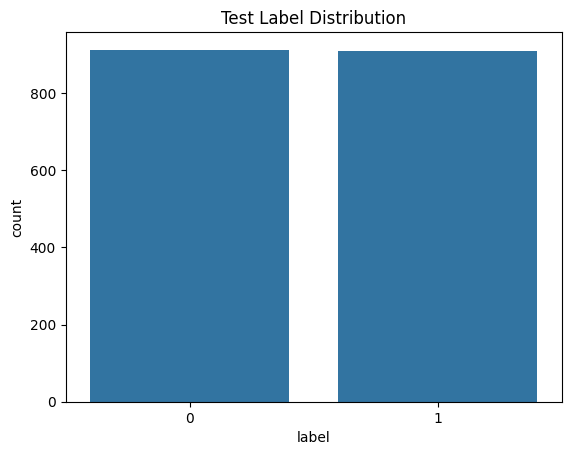

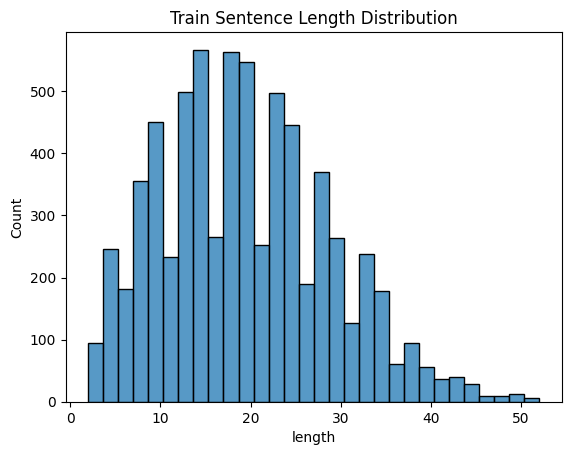

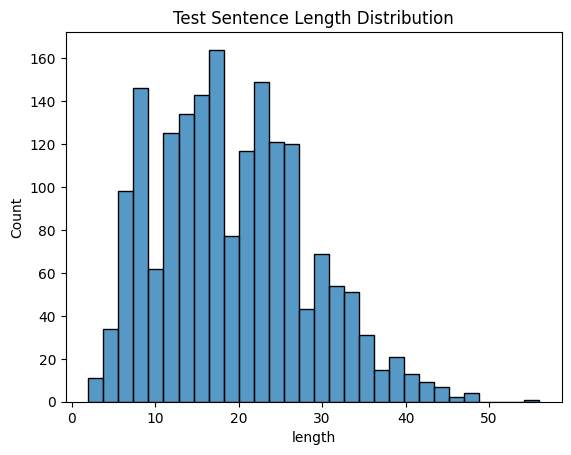

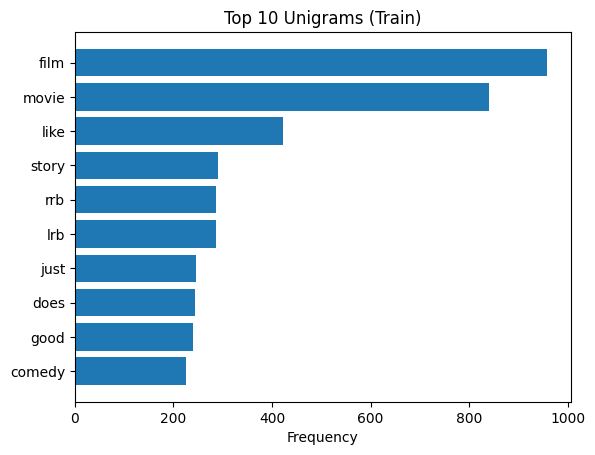

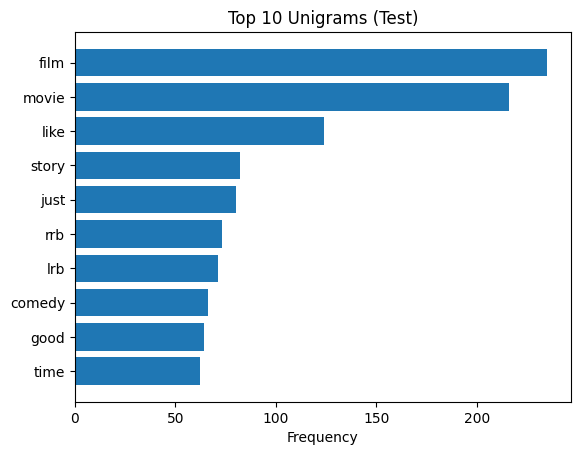

In [ ]:
# =========================
# 2. EDA
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer


# Class distribution(train)
print("Train distribution:\n", train_data["label"].value_counts())
sns.countplot(x=train_data["label"])
plt.title("Train Label Distribution")
plt.show()

# Class distribution (test)
print("Test distribution:\n", test_data["label"].value_counts())
sns.countplot(x=test_data["label"])
plt.title("Test Label Distribution")
plt.show()

# Sentence length (train)
train_data["length"] = train_data["text"].apply(lambda x: len(x.split()))
sns.histplot(train_data["length"], bins=30)
plt.title("Train Sentence Length Distribution")
plt.show()

# Sentence length (test)
test_data["length"] = test_data["text"].apply(lambda x: len(x.split()))
sns.histplot(test_data["length"], bins=30)
plt.title("Test Sentence Length Distribution")
plt.show()

# Unigram
def plot_unigram(texts, title):
    vectorizer = CountVectorizer(stop_words='english', ngram_range=(1,1))
    X = vectorizer.fit_transform(texts)

    words = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1

    df = pd.DataFrame({'word': words, 'count': counts})
    df = df.sort_values(by='count', ascending=False).head(10)

    plt.figure()
    plt.barh(df['word'], df['count'])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Frequency")
    plt.show()

#  Unigram（train)
plot_unigram(train_data["text"], "Top 10 Unigrams (Train)")

# Unigram（test)
plot_unigram(test_data["text"], "Top 10 Unigrams (Test)")

From both the training and test datasets, the distribution of positive and negative samples is relatively balanced, with only slight imbalance, which is beneficial for model learning and fair evaluation. The sentence lengths are mainly concentrated between 5 and 30 words, showing a stable distribution, indicating that the texts are of moderate length and consistent, which is helpful for feature extraction. There are only a few longer sentences, which have minimal impact on the overall dataset. The unigram results are very similar, showing that the data split is balanced. The most common words, such as “film” and “movie,” confirm that the dataset is about movie reviews. Words like “like” and “good” indicate sentiment, while “story” and “comedy” describe movie content. Overall, the training and test sets exhibit similar distributions in class balance, sentence length and word usage, providing a reliable foundation for model training and evaluation.

In [ ]:
# =========================
# 3. Split (80/20)
# =========================
X = train_data["text"]
y = train_data["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 4. TF-IDF
# =========================
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(test_data["text"])


In [ ]:
# =========================
# 5. SVM (with 10-fold CV)
# =========================

svm_model = LinearSVC()

kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Perform 10-fold cross validation
svm_cv = cross_val_score(svm_model, X_train_tfidf, y_train, cv=kf, scoring="accuracy")
print("SVM CV mean:", np.mean(svm_cv))

svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Results:")
print(classification_report(test_data["label"], svm_pred))

SVM CV mean: 0.7568706301695381
SVM Results:
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       912
           1       0.76      0.79      0.78       909

    accuracy                           0.77      1821
   macro avg       0.77      0.77      0.77      1821
weighted avg       0.77      0.77      0.77      1821



In [ ]:
# =========================
# 6. Decision Tree (with 10-fold CV)
# =========================

dt_model = DecisionTreeClassifier(max_depth=20)

dt_cv = cross_val_score(dt_model, X_train_tfidf, y_train, cv=kf, scoring="accuracy")
print("Decision Tree CV mean:", np.mean(dt_cv))

dt_model.fit(X_train_tfidf, y_train)
dt_pred = dt_model.predict(X_test_tfidf)

print("Decision Tree Results:")
print(classification_report(test_data["label"], dt_pred))

Decision Tree CV mean: 0.5802005470652366
Decision Tree Results:
              precision    recall  f1-score   support

           0       0.69      0.27      0.39       912
           1       0.55      0.88      0.67       909

    accuracy                           0.57      1821
   macro avg       0.62      0.57      0.53      1821
weighted avg       0.62      0.57      0.53      1821



In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.8 MB/s eta 0:00:00


In [ ]:
# =========================
# 7. Word2Vec-based model
# =========================

from gensim.models import Word2Vec

# Tokenize text
tokenized = [text.split() for text in train_data["text"]]

# Train Word2Vec
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=2)

# Convert sentence to average word vectors
def get_avg_vector(sentence):
    words = sentence.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vectors, axis=0) if len(vectors) > 0 else np.zeros(100)

X_train_w2v = np.array([get_avg_vector(x) for x in X_train])
X_test_w2v = np.array([get_avg_vector(x) for x in test_data["text"]])

# Train classifier (Logistic Regression)
from sklearn.linear_model import LogisticRegression

w2v_clf = LogisticRegression(max_iter=1000)
w2v_clf.fit(X_train_w2v, y_train)

w2v_pred = w2v_clf.predict(X_test_w2v)

print("Word2Vec Results:")
print(classification_report(test_data["label"], w2v_pred))


Word2Vec Results:
              precision    recall  f1-score   support

           0       0.63      0.42      0.50       912
           1       0.56      0.75      0.64       909

    accuracy                           0.59      1821
   macro avg       0.60      0.59      0.57      1821
weighted avg       0.60      0.59      0.57      1821



In [ ]:
# =========================
# 8. BERT model
# =========================

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# Convert to Dataset
train_df, test_df = train_test_split(train_data, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=64)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

# Model
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    num_train_epochs=3,
    logging_dir="./logs"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

# Evaluation
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print("BERT Results:")
print(classification_report(y_true, y_pred))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5536 [00:00<?, ? examples/s]

...

Step,Training Loss
500,0.314248
1000,0.099560


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Results:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       671
           1       0.91      0.91      0.91       713

    accuracy                           0.91      1384
   macro avg       0.91      0.91      0.91      1384
weighted avg       0.91      0.91      0.91      1384



We selected SVM, Decision Tree, Word2Vec, and BERT models for comparison, and we found that the models show clear differences in performance on this text classification task. Among the traditional models, the SVM performs the best, with a cross-validation mean accuracy of approximately 0.76 and a test accuracy of 0.77. Its precision, recall, and F1-score are all around 0.77, indicating balanced and stable performance across both classes. In contrast, the Decision Tree performs poorly, with a CV mean of about 0.58 and test accuracy of 0.57. Its precision and recall are highly uneven, for example, it achieves high recall 0.88 for class 1 but very low recall 0.27 for class 0, suggesting strong bias toward one class. The Word2Vec-based model performs slightly better than the Decision Tree but remains relatively weak overall, with an accuracy of about 0.59 and precision, recall, and F1-scores ranging between 0.57 and 0.64, indicating limited effectiveness in capturing semantic information for this task.

In comparison, the BERT-based model achieves the best performance, with an accuracy of 0.91 and precision, recall, and F1-score all around 0.91. This demonstrates that BERT can effectively capture contextual and semantic information, leading to significantly better and more balanced classification results. In summary, BERT is the most effective model for this task, while SVM is the strongest among traditional methods. Decision Tree and Word2Vec are less suitable for high-dimensional text data and show comparatively weaker performance.

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


In [ ]:
# ==============================
# Import libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import silhouette_score

# BERT embedding
from sentence_transformers import SentenceTransformer

# ==============================
# Load Dataset
# ==============================
df = pd.read_csv("Amazon_Unlocked_Mobile.csv")

print(df.shape)
df.head()

(413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0



Missing values:
Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64


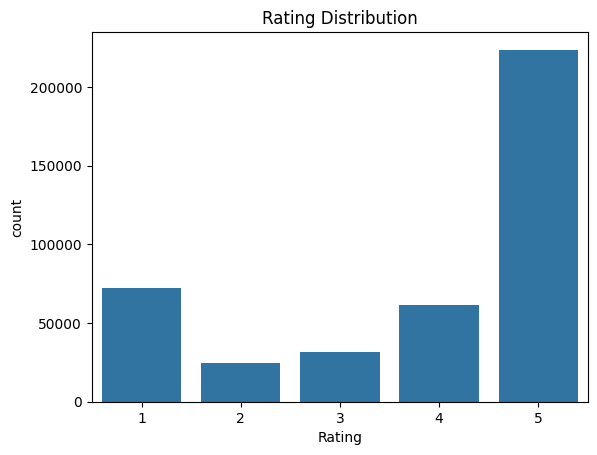

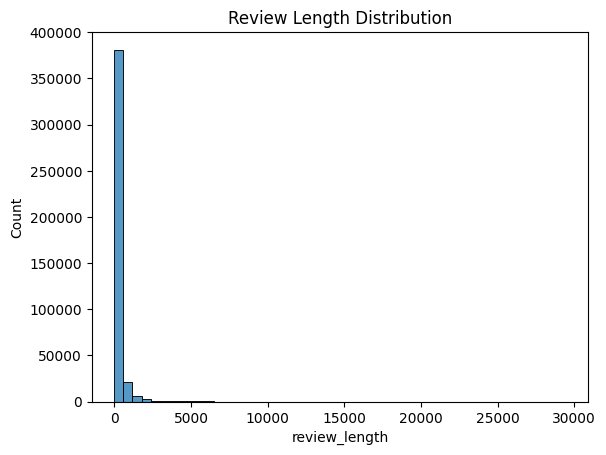

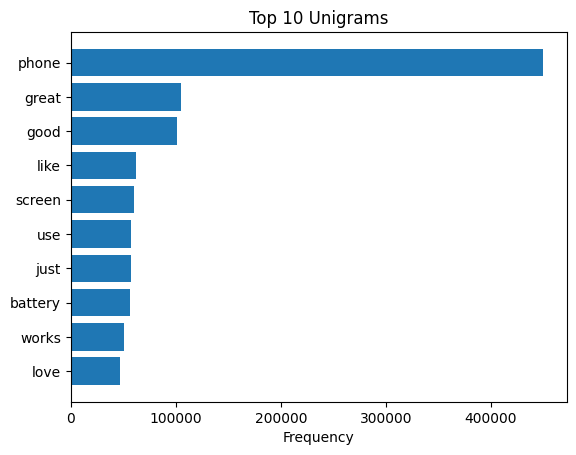

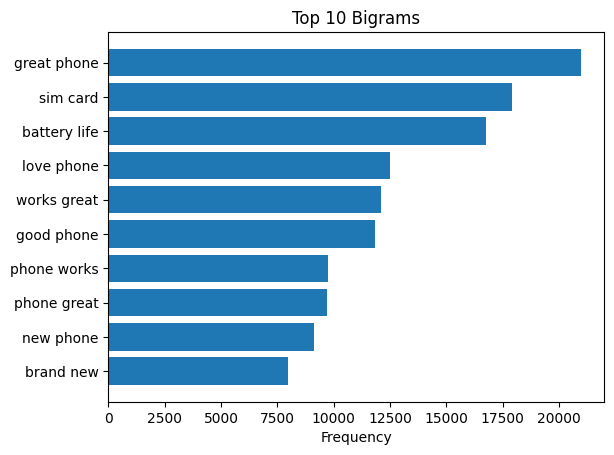

In [ ]:
# ==============================
# EDA
# ==============================

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Drop missing reviews
df = df.dropna(subset=["Reviews"])

# Rating distribution
plt.figure()
sns.countplot(x="Rating", data=df)
plt.title("Rating Distribution")
plt.show()

# Review length
df["review_length"] = df["Reviews"].apply(lambda x: len(str(x)))

plt.figure()
sns.histplot(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.show()

from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Unigram
vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1,1),
    max_features=10
)

X = vectorizer.fit_transform(df["Reviews"])
words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
word_freq = sorted(zip(words, counts), key=lambda x: x[1], reverse=True)
labels, values = zip(*word_freq)

plt.figure()
plt.barh(labels, values)
plt.xlabel("Frequency")
plt.title("Top 10 Unigrams")
plt.gca().invert_yaxis()
plt.show()

# Bigram
vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2,2),
    max_features=10
)

X = vectorizer.fit_transform(df["Reviews"])
bigrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
bigram_freq = sorted(zip(bigrams, counts), key=lambda x: x[1], reverse=True)
labels, values = zip(*bigram_freq)

plt.figure()
plt.barh(labels, values)
plt.xlabel("Frequency")
plt.title("Top 10 Bigrams")
plt.gca().invert_yaxis()
plt.show()

In this dataset, Product Name and Rating have no missing values, so they are reliable. Reviews also has very few missing values and can be used for text analysis. However, Brand Name and Review Votes have many missing values, so they are less useful. Price has some missing values but can be handled. Overall, the dataset is good for text analysis but has some missing information in other fields.

The rating distribution shows that most reviews are 5 stars, with a noticeable number of 1 star ratings, while middle ratings are less common. This indicates a polarized pattern where users tend to give either very positive or very negative feedback. The review length analysis shows that most reviews are short, but there are some very long reviews, resulting in a right-skewed distribution. This suggests that while many users leave brief comments, a smaller number provide detailed feedback.

The unigram analysis shows that “phone” is the most frequent word, indicating the main focus of the reviews. Other common words such as “great,” “good,” “love,” and “like” suggest that many reviews have a positive sentiment. Words like “battery” and “screen” highlight key product features discussed by users. The bigram analysis shows that the most frequent two-word phrases are mainly positive, such as “great phone,” “good phone,” and “works great.” Other common phrases like “battery life” and “sim card” indicate key topics discussed by users. Overall, the results suggest that most reviews focus on product quality and functionality, with a generally positive sentiment.

K and Silhouette Scores:
K=2, Score=0.3048
K=3, Score=0.2185
K=4, Score=0.2051
K=5, Score=0.2251
K=6, Score=0.0631
K=7, Score=0.0687
K=8, Score=0.1842
K=9, Score=0.1888

Best K: 2
Final Silhouette: 0.30477785105754013


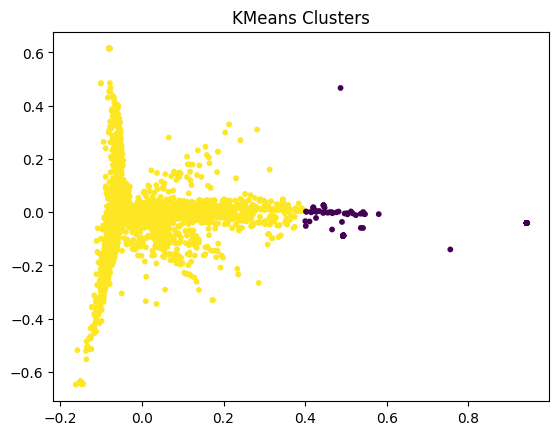

In [ ]:
import re

# ==============================
# Text Cleaning
# ==============================
def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'[^a-z\s]', '', text)         # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

# Sample for faster computation
df = df.sample(n=10000, random_state=42)

df["clean_reviews"] = df["Reviews"].apply(clean_text)

# ==============================
# TF-IDF
# ==============================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    min_df=8,
    max_df=0.8,
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(df["clean_reviews"])

# =============================
# Dimensionality Reduction (SVD)
# ==============================

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

# ==============================
# Find Best K
# ==============================

scores = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    scores.append(score)

print("K and Silhouette Scores:")
for k, s in zip(K_range, scores):
    print(f"K={k}, Score={s:.4f}")
best_k = K_range[np.argmax(scores)]
print("\nBest K:", best_k)

# ==============================
# Final KMeans
# ==============================

kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(X_reduced)
print("Final Silhouette:", silhouette_score(X_reduced, labels))

# ==============================
# Visualization (PCA)
# ==============================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_reduced)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=10)
plt.title("KMeans Clusters")
plt.show()

The KMeans results show that K=2 is the best choice, with the highest silhouette score of 0.30. This means the data is best divided into two clusters. The KMeans plot shows two clusters that are mostly separated, with a large cluster on the left and a smaller one on the right. The boundary is not very clear, and the clusters are imbalanced. Overall, the result is acceptable but not very strong.

Testing different eps values:
eps=0.3, clusters=56, noise=8383, silhouette=-0.1337
eps=0.5, clusters=56, noise=8381, silhouette=-0.1336
eps=0.7, clusters=56, noise=8361, silhouette=-0.1322
eps=1.0, clusters=59, noise=8319, silhouette=-0.1312

Best eps: 1.0, Best Silhouette: -0.1312


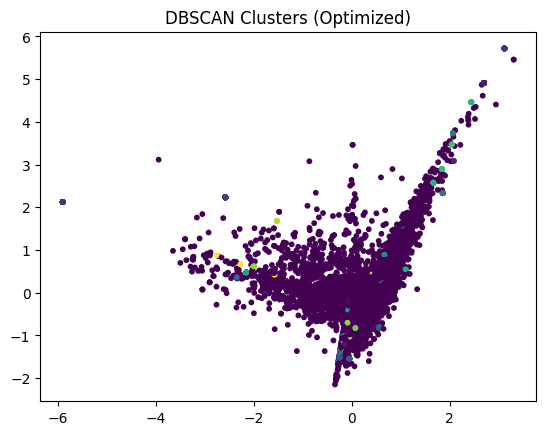

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Feature scaling
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

# ==============================
# Parameter tuning
# ==============================
eps_values = [0.3, 0.5, 0.7, 1.0]

best_eps = None
best_score = -1

print("Testing different eps values:")

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        try:
            score = silhouette_score(X_scaled, labels)
        except:
            score = -1
    else:
        score = -1

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    print(f"eps={eps}, clusters={n_clusters}, noise={noise}, silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_eps = eps

print(f"\nBest eps: {best_eps}, Best Silhouette: {best_score:.4f}")

# ==============================
# Final model
# ==============================
dbscan = DBSCAN(eps=best_eps, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# ==============================
# Visualization
# ==============================
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='viridis', s=10)
plt.title("DBSCAN Clusters (Optimized)")
plt.show()

The DBSCAN results show many clusters with a very large number of noise points and a very low silhouette score -0.13, indicating poor clustering performance. Changing the eps value has little effect, suggesting the issue is due to the high-dimensional text data. The scatter plot also shows no clear separation, confirming that DBSCAN fails to capture meaningful cluster structures.

K=2, Silhouette=0.3168
K=3, Silhouette=0.2756
K=4, Silhouette=0.2885
K=5, Silhouette=0.2187
K=6, Silhouette=0.2273
K=7, Silhouette=0.2315
K=8, Silhouette=0.2371
K=9, Silhouette=0.2346

Best K: 2
Final clusters: {np.int64(0), np.int64(1)}


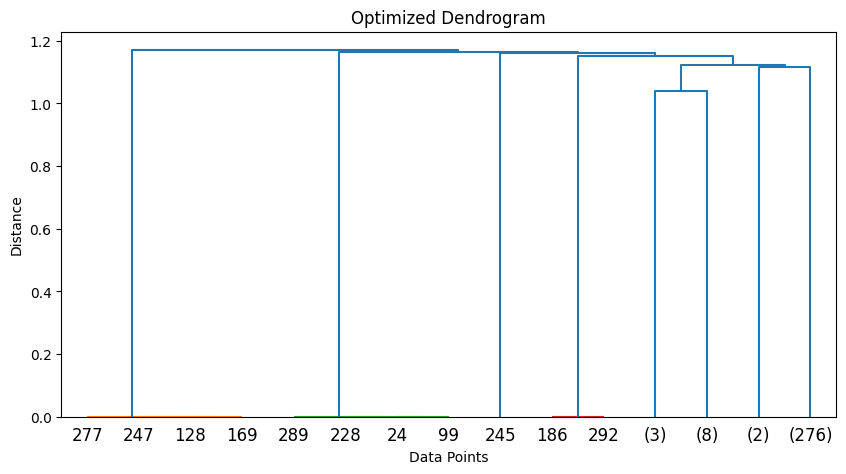

In [ ]:
# ==============================
# Hierarchical Clustering
# ==============================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# ==============================
# Find optimal number of clusters
# ==============================

# Try different values of K and compute silhouette score
K_range = range(2, 10)
scores = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k)
    labels = hc.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    scores.append(score)
    print(f"K={k}, Silhouette={score:.4f}")

# Select best K
best_k = K_range[scores.index(max(scores))]
print("\nBest K:", best_k)

# ==============================
# Final Hierarchical model
# ==============================

# Train model using best K
hc = AgglomerativeClustering(n_clusters=best_k)
hc_labels = hc.fit_predict(X_reduced)

print("Final clusters:", set(hc_labels))

# ==============================
# Dendrogram Visualization
# ==============================

sample = X_reduced[:300]
linked = linkage(sample, method='average')

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='level', p=5)
plt.axhline(y=3, color='r', linestyle='--')
plt.title("Optimized Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

The hierarchical clustering results show that K=2 has the highest silhouette score 0.32, indicating that dividing the data into two clusters gives the best performance. When K increases to 3 or more, the silhouette score decreases, meaning further splitting reduces clustering quality. Therefore, K=2 is the most appropriate choice.

From the dendrogram, most data points are merged at low distances, suggesting high similarity among the data and a lack of clear hierarchical structure. This is why the clusters are not clearly separated in the visualization.  Overall, the result is acceptable, but the cluster structure is not very distinct, which is common in high-dimensional text data.

In [ ]:
# ==============================
# BERT-based Clustering
# ==============================

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# ==============================
# 1. Load BERT model
# ==============================
model = SentenceTransformer('all-MiniLM-L6-v2')

# ==============================
# 2. Generate embeddings
# ==============================
X_bert = model.encode(df["clean_reviews"].tolist(), show_progress_bar=True)

# ==============================
# 3. Normalize embeddings
# ==============================
X_bert = normalize(X_bert)

# ==============================
# 4. Find optimal K
# ==============================
scores = []
K_range = range(2, 10)

print("Testing different K values:")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_bert)
    score = silhouette_score(X_bert, labels, metric='cosine')
    scores.append(score)
    print(f"K={k}, Score={score:.4f}")

# Select best K
best_k = K_range[scores.index(max(scores))]
print("\nBest K:", best_k)

# ==============================
# 5. Final model
# ==============================
kmeans_bert = KMeans(n_clusters=best_k, random_state=42)
bert_labels = kmeans_bert.fit_predict(X_bert)

final_score = silhouette_score(X_bert, bert_labels, metric='cosine')
print("Final Silhouette:", final_score)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Testing different K values:
K=2, Score=0.2028
K=3, Score=0.1053
K=4, Score=0.1010
K=5, Score=0.0964
K=6, Score=0.0479
K=7, Score=0.0446
K=8, Score=0.0598
K=9, Score=0.0595

Best K: 2
Final Silhouette: 0.20279244


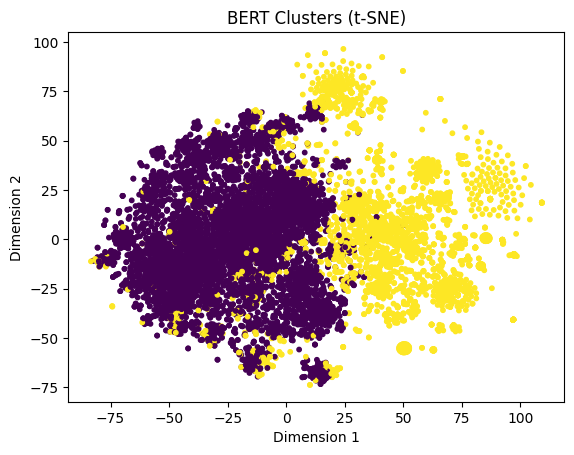

In [ ]:
# ==============================
# Visualization (BERT Clusters)
# ==============================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce BERT embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_bert)

# Plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=bert_labels, cmap='viridis', s=10)
plt.title("BERT Clusters (t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

The results show that K=2 gives the highest silhouette score 0.20, indicating it is the best choice among the tested values. When K increases, the score decreases, meaning the clustering becomes less effective. This suggests that the data is best divided into two main groups.

The BERT clustering visualization shows two main groups, which is consistent with the optimal K=2 result. One cluster is mainly located on the left side, while the other is more concentrated on the right. There is some overlap in the middle region, indicating that the separation between clusters is not very clear.

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**

The results show clear differences among the clustering methods. KMeans performs reasonably well, with K=2 giving the best silhouette score 0.3, and the visualization shows two main groups. DBSCAN performs poorly, as most data points are classified as noise, and the scatter plot shows no clear cluster structure, indicating it fails to capture meaningful patterns in the data. Hierarchical clustering produces similar results to KMeans, with K=2 being optimal, but the dendrogram shows weak separation and no clear hierarchical structure. BERT-based clustering provides a more structured distribution and better captures semantic relationships in the data. Although the silhouette score is still moderate, the visualization shows clearer grouping compared to TF-IDF methods.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

